In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import json

# Load the JSON file
file_path = "excuis_final_cleaned.json"
with open(file_path, "r") as f:
    data = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(data)
df.head()

,title,ingredients,instructions,name_clean
0,Prosciutto-Wrapped Pork Tenderloin with Crispy...,"[1 pound pork tenderloin, salt and ground blac...",[Preheat oven to 350 degrees F (175 degrees C)...,prosciutto-wrapped pork tenderloin with crispy...
1,Ground Beef and Cabbage,"[1 large head cabbage, finely chopped, 1 (14.5...","[Gather all ingredients., Place cabbage, tomat...",ground beef and cabbage
2,Breaded Air Fryer Pork Chops,"[4 (5 ounce) boneless, center-cut pork chops, ...",[Preheat an air fryer to 400 degrees F (200 de...,breaded air fryer pork chops
3,Simple BBQ Ribs,"[2.5 pounds country-style pork ribs, 2 tablesp...",[Make the perfect ribs without the grill using...,simple bbq ribs
4,How to Cook Trout,"[0.25 cup butter, 2 (8 ounce) whole trout, but...",[Melt butter in a saucepan over medium-low hea...,how to cook trout


In [ ]:
# Total number of recipes
total_recipes = len(df)

# Check for missing values
missing_values = df.isnull().sum()

# Ingredient and instruction length distributions
df["num_ingredients"] = df["ingredients"].apply(len)
df["num_instructions"] = df["instructions"].apply(len)

# Summary stats
summary_stats = df[["num_ingredients", "num_instructions"]].describe()

total_recipes, missing_values, summary_stats


(1097,
 title           0
 ingredients     0
 instructions    0
 name_clean      0
 dtype: int64,
        num_ingredients  num_instructions
 count      1097.000000       1097.000000
 mean          9.534184          7.296263
 std           4.234780          6.418546
 min           3.000000          0.000000
 25%           6.000000          3.000000
 50%           9.000000          5.000000
 75%          12.000000          8.000000
 max          29.000000         33.000000)

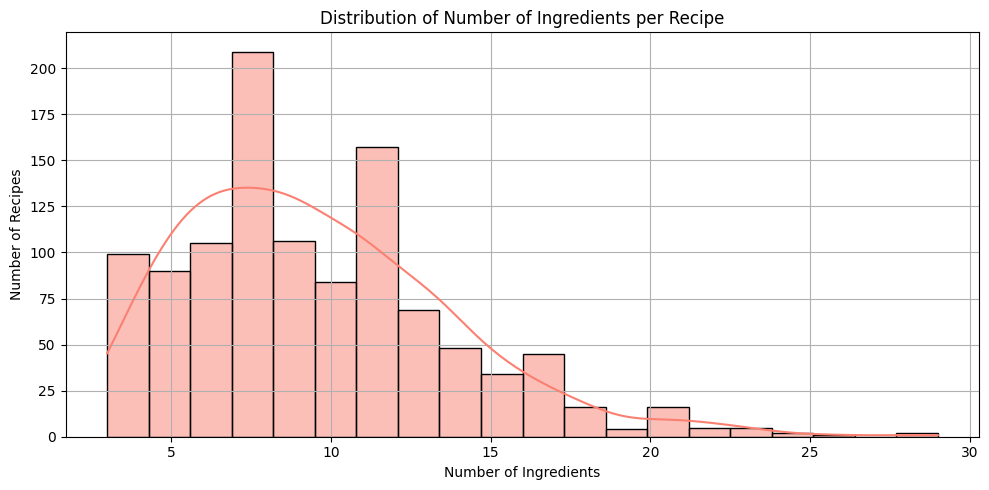

In [ ]:
# Plot 1: Distribution of number of ingredients per recipe
plt.figure(figsize=(10, 5))
sns.histplot(df["num_ingredients"], bins=20, kde=True, color='salmon')
plt.title("Distribution of Number of Ingredients per Recipe")
plt.xlabel("Number of Ingredients")
plt.ylabel("Number of Recipes")
plt.grid(True)
plt.tight_layout()
plt.show()


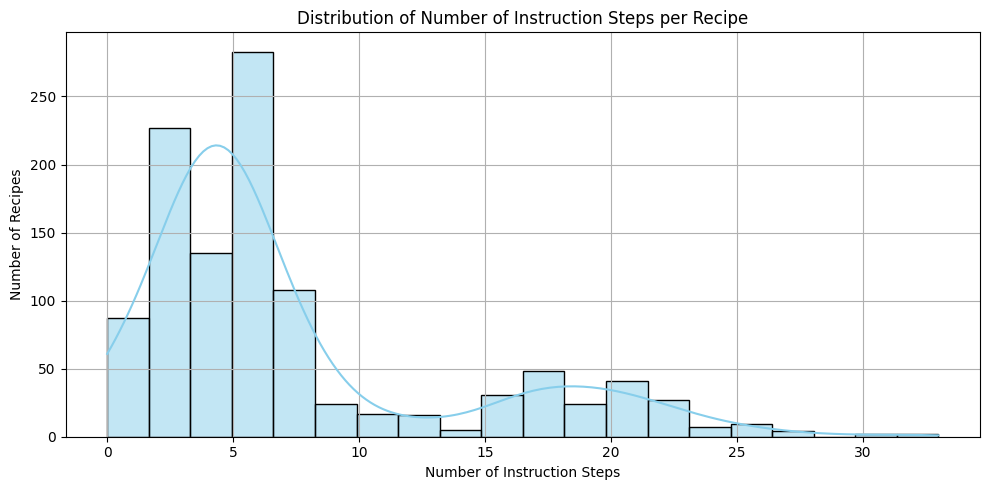

In [ ]:
# Plot 2: Distribution of number of instruction steps per recipe
plt.figure(figsize=(10, 5))
sns.histplot(df["num_instructions"], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Number of Instruction Steps per Recipe")
plt.xlabel("Number of Instruction Steps")
plt.ylabel("Number of Recipes")
plt.grid(True)
plt.tight_layout()
plt.show()


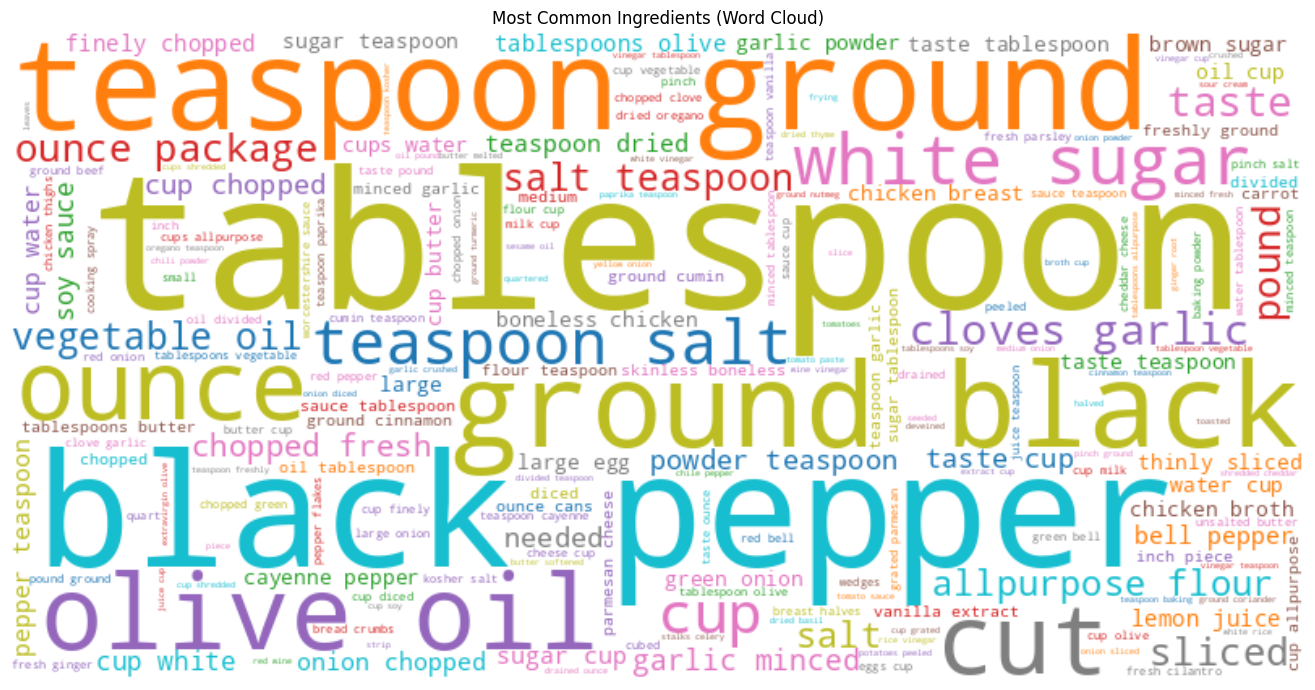

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Flatten the ingredient list and clean them up
ingredient_list = [ingredient.lower() for sublist in df['ingredients'] for ingredient in sublist]

# Optional: Remove quantities & units using regex (basic filter)
import re
def clean_ingredient(ing):
    return re.sub(r'[^a-zA-Z\s]', '', ing).strip()

cleaned_ingredients = [clean_ingredient(ing) for ing in ingredient_list if ing.strip()]

# Join into a single string
ingredient_text = " ".join(cleaned_ingredients)

# Generate Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='tab10').generate(ingredient_text)

# Plot
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Ingredients (Word Cloud)")
plt.tight_layout()
plt.show()

<ipython-input-7-52cf753a81bf>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(ingredients), palette="rocket")


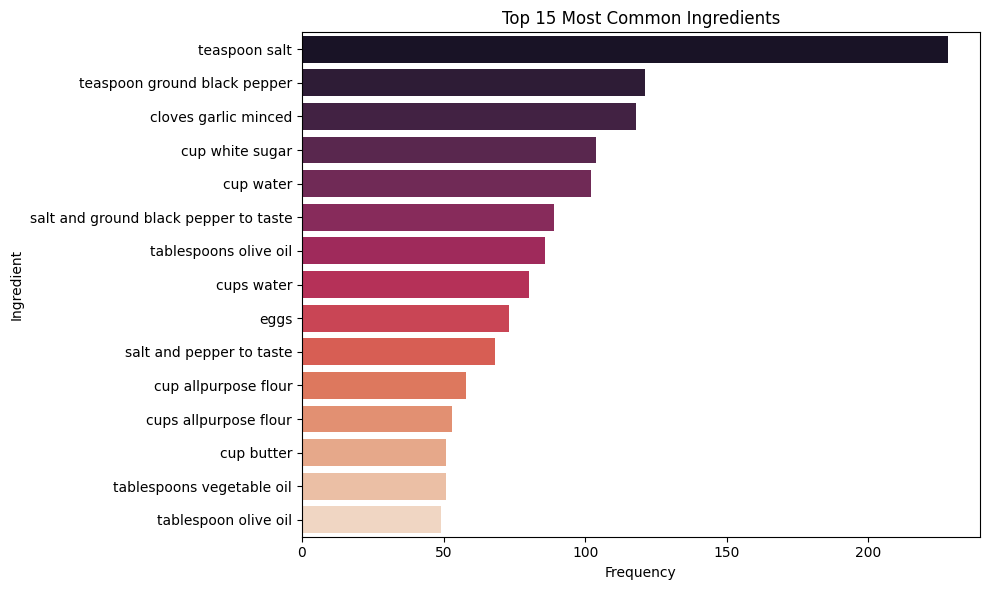

In [ ]:
from collections import Counter

# Count ingredient frequencies
ingredient_counts = Counter(cleaned_ingredients)
top_ingredients = ingredient_counts.most_common(15)

# Prepare for plotting
ingredients, counts = zip(*top_ingredients)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(ingredients), palette="rocket")
plt.title("Top 15 Most Common Ingredients")
plt.xlabel("Frequency")
plt.ylabel("Ingredient")
plt.tight_layout()
plt.show()


In [ ]:
# Longest and shortest recipes by number of instructions
longest_instructions = df.loc[df['num_instructions'].idxmax()]
shortest_instructions = df.loc[df['num_instructions'].idxmin()]

# Longest and shortest by number of ingredients
longest_ingredients = df.loc[df['num_ingredients'].idxmax()]
shortest_ingredients = df.loc[df['num_ingredients'].idxmin()]

# Print summary
print("📖 Longest Instructions:\n", longest_instructions["title"], "-", len(longest_instructions["instructions"]), "steps")
print("📖 Shortest Instructions:\n", shortest_instructions["title"], "-", len(shortest_instructions["instructions"]), "steps")

print("\n🧂 Most Ingredients:\n", longest_ingredients["title"], "-", len(longest_ingredients["ingredients"]), "ingredients")
print("🧂 Least Ingredients:\n", shortest_ingredients["title"], "-", len(shortest_ingredients["ingredients"]), "ingredients")


📖 Longest Instructions:
 Easy Mochi - 33 steps
📖 Shortest Instructions:
 World&#39;s Best Honey Garlic Pork Chops - 0 steps

🧂 Most Ingredients:
 Chef John&#39;s Mulligatawny Soup - 29 ingredients
🧂 Least Ingredients:
 Easy Baked Chicken Thighs - 3 ingredients


In [ ]:
print("\n".join(longest_instructions["instructions"]))


Satisfy your sweet tooth with homemade mochi. Trust us: The process is way simpler than you think. This easy mochi recipe comes together quickly with just a few ingredients.
Mochi is a bun-shaped Japanese dessert made from sweet glutinous rice flour, or mochigome. It has a soft, chewy texture that is somewhat elastic. Mochi is often flavored with matcha (or green tea powder), which gives it a light green hue.
Learn more: What Is Mochi and How Do You Make It at Home?
"Mochi" is pronounced "MOE-chee."
Here's what you'll need to make homemade mochi:
Red Bean Paste
You can buy sweetened red bean paste (also called adzuki bean paste or anko) at the store or you can make it at home with our easy recipe.
Glutinous Rice FlourMake sure to get glutinous rice flour (mochigome) instead of regular rice flour. This ingredient is essential for mochi's signature chewy texture.
Green Tea PowderGreen tea powder (or matcha) has a complex, earthy flavor that works well with mochi. Plus, it gives the desse

Basis of Clustering-

TF-IDF vectorization on the instructions_text field, followed by KMeans clustering.

So the clusters are formed based on:

✨ Similarity in the language and wording of the cooking instructions ✨
Not the ingredients. Not the title. But the actual style and content of the instructions.

What That Means in Practice:
TF-IDF turns the instructions into a matrix of word importance.

KMeans groups together recipes that use similar steps, verbs, and flow.

So recipes that involve similar:

Cooking methods (e.g., "boil", "steam", "bake", "fry")

Utensils/tools (e.g., "instant pot", "skillet", "oven")

Styles (e.g., desserts vs. savory, cold prep vs. hot)

…tend to end up in the same cluster.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import pandas as pd

# Combine instructions into single strings
df["instructions_text"] = df["instructions"].apply(lambda x: " ".join(x).lower())

# Use TF-IDF on instructions
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(df["instructions_text"])

# Cluster into 5 types
kmeans = KMeans(n_clusters=5, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

# View sample titles per cluster
for i in range(5):
    print(f"\n📦 Cluster {i}:")
    print(df[df["cluster"] == i]["title"].sample(5, random_state=42).tolist())



📦 Cluster 0:
['Coffee Jelly', 'Copycat KFC Coleslaw', 'Pineapple Sunrise', 'The Ultimate Pasta Salad', 'Chai Tea Latte']

📦 Cluster 1:
['Quick and Easy Pancit', 'Best Meatloaf', 'Instant Pot Best Beef Stew', 'Beer Batter Fish Made Great', 'Ukrainian Red Borscht Soup']

📦 Cluster 2:
['Goan Pork Vindaloo', 'Ginataang Manok (Chicken Cooked in Coconut Milk)', 'Shrimp with Lobster Sauce', 'Breakfast Rice from Japan', 'Greek Green Beans']

📦 Cluster 3:
['Marshmallow Hot Fudge Sauce', 'Mamon (Sponge Cakes)', 'Éclair Cake', 'German Rocks', 'Roasted Cauliflower Salad']

📦 Cluster 4:
['Japanese Ginger Pork', 'Grilled Swordfish', 'Fantastic Lemon Butter Fillet', 'Sheet Pan Ground Beef, Potato, and Carrot Dinner', 'Easy Sweet Potato Casserole']
